In [46]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib as mpl

import scipy
import numpy as np
np.random.seed(42)
import ipywidgets as widgets

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [47]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [48]:
GRID_SIZE = 25
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.2
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10

FS = 250000
ASSUMED_BAT_SPEED = 4*np.sqrt(3)/3 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)

In [49]:
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
UBNA_ARRAY_MIC_LOCS =  (254/10000) * np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])
UBNA_ARRAY_MIC_LOCS

array([[-0.44958  , -0.9525   ,  0.8048625],
       [-0.44958  ,  0.9525   ,  0.8048625],
       [-0.44958  , -0.9525   ,  0.       ],
       [-0.44958  ,  0.9525   ,  0.       ],
       [-0.44958  , -0.5334   , -0.739775 ],
       [-0.44958  ,  0.5334   , -0.739775 ],
       [ 0.       ,  0.       ,  0.8048625],
       [ 0.       ,  0.       ,  0.       ]])

In [50]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 7
MICROPHONES_USED = np.array([1,2,3,4,5,6,7,8])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

In [105]:
N = UBNA_ARRAY_MIC_LOCS.shape[0]
rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
A_locs_mat_wrt_ref_channel = A_LOCS_MAT
A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))

trace_offsets = 2.5e-4 * np.linspace(-0.1, 0.1, N)

time_transmitted = TIME_DURATION/2
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
template_signal = raw_signal[:int(FS*0.01)]
signal = np.zeros(t.size)
signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
signal_duration = TIME_DURATION/2

time_step = 1
time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
pos_x = x_arr[time_idx]
pos_y = y_arr[time_idx]
pos_z = z_arr[time_idx]

dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
receive_signaln_for_timestep = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * FS))
rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

In [106]:
example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
example_calls.shape

(11, 8, 25000)

In [128]:
noise_power_dB = 0 # dBFS
noise_power_lin = 10**(noise_power_dB/10)
noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)

noisy_calls = example_calls + noise_mat

In [129]:
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SPEC_NFFT = 32

In [130]:
def extract_reference_call_only(ref_call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(SPEC_NFFT))
    f, t, Sxx = scipy.signal.spectrogram(ref_call_segment, FS, detrend=False,
                                nfft=SPEC_NFFT, 
                                window=mpl_specgram_window)
    Sxx[np.where(Sxx==0)] = 1e-16 ### <--- replace all zeros with very small values (-160dB) outside of the scale to avoid taking log10(0)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(0.008))
    found_call_start = int(FS*(peak_freq_time[0] - 0.004))
    
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only, found_call_start/FS, found_call_dur/FS

def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:], np.argmax(feature[detection_index])

TEMPLATE_CHANNEL = 3
def index_reference_call_based_on_channel(calls, detection_index, channel):
    return calls[detection_index, channel,:], channel

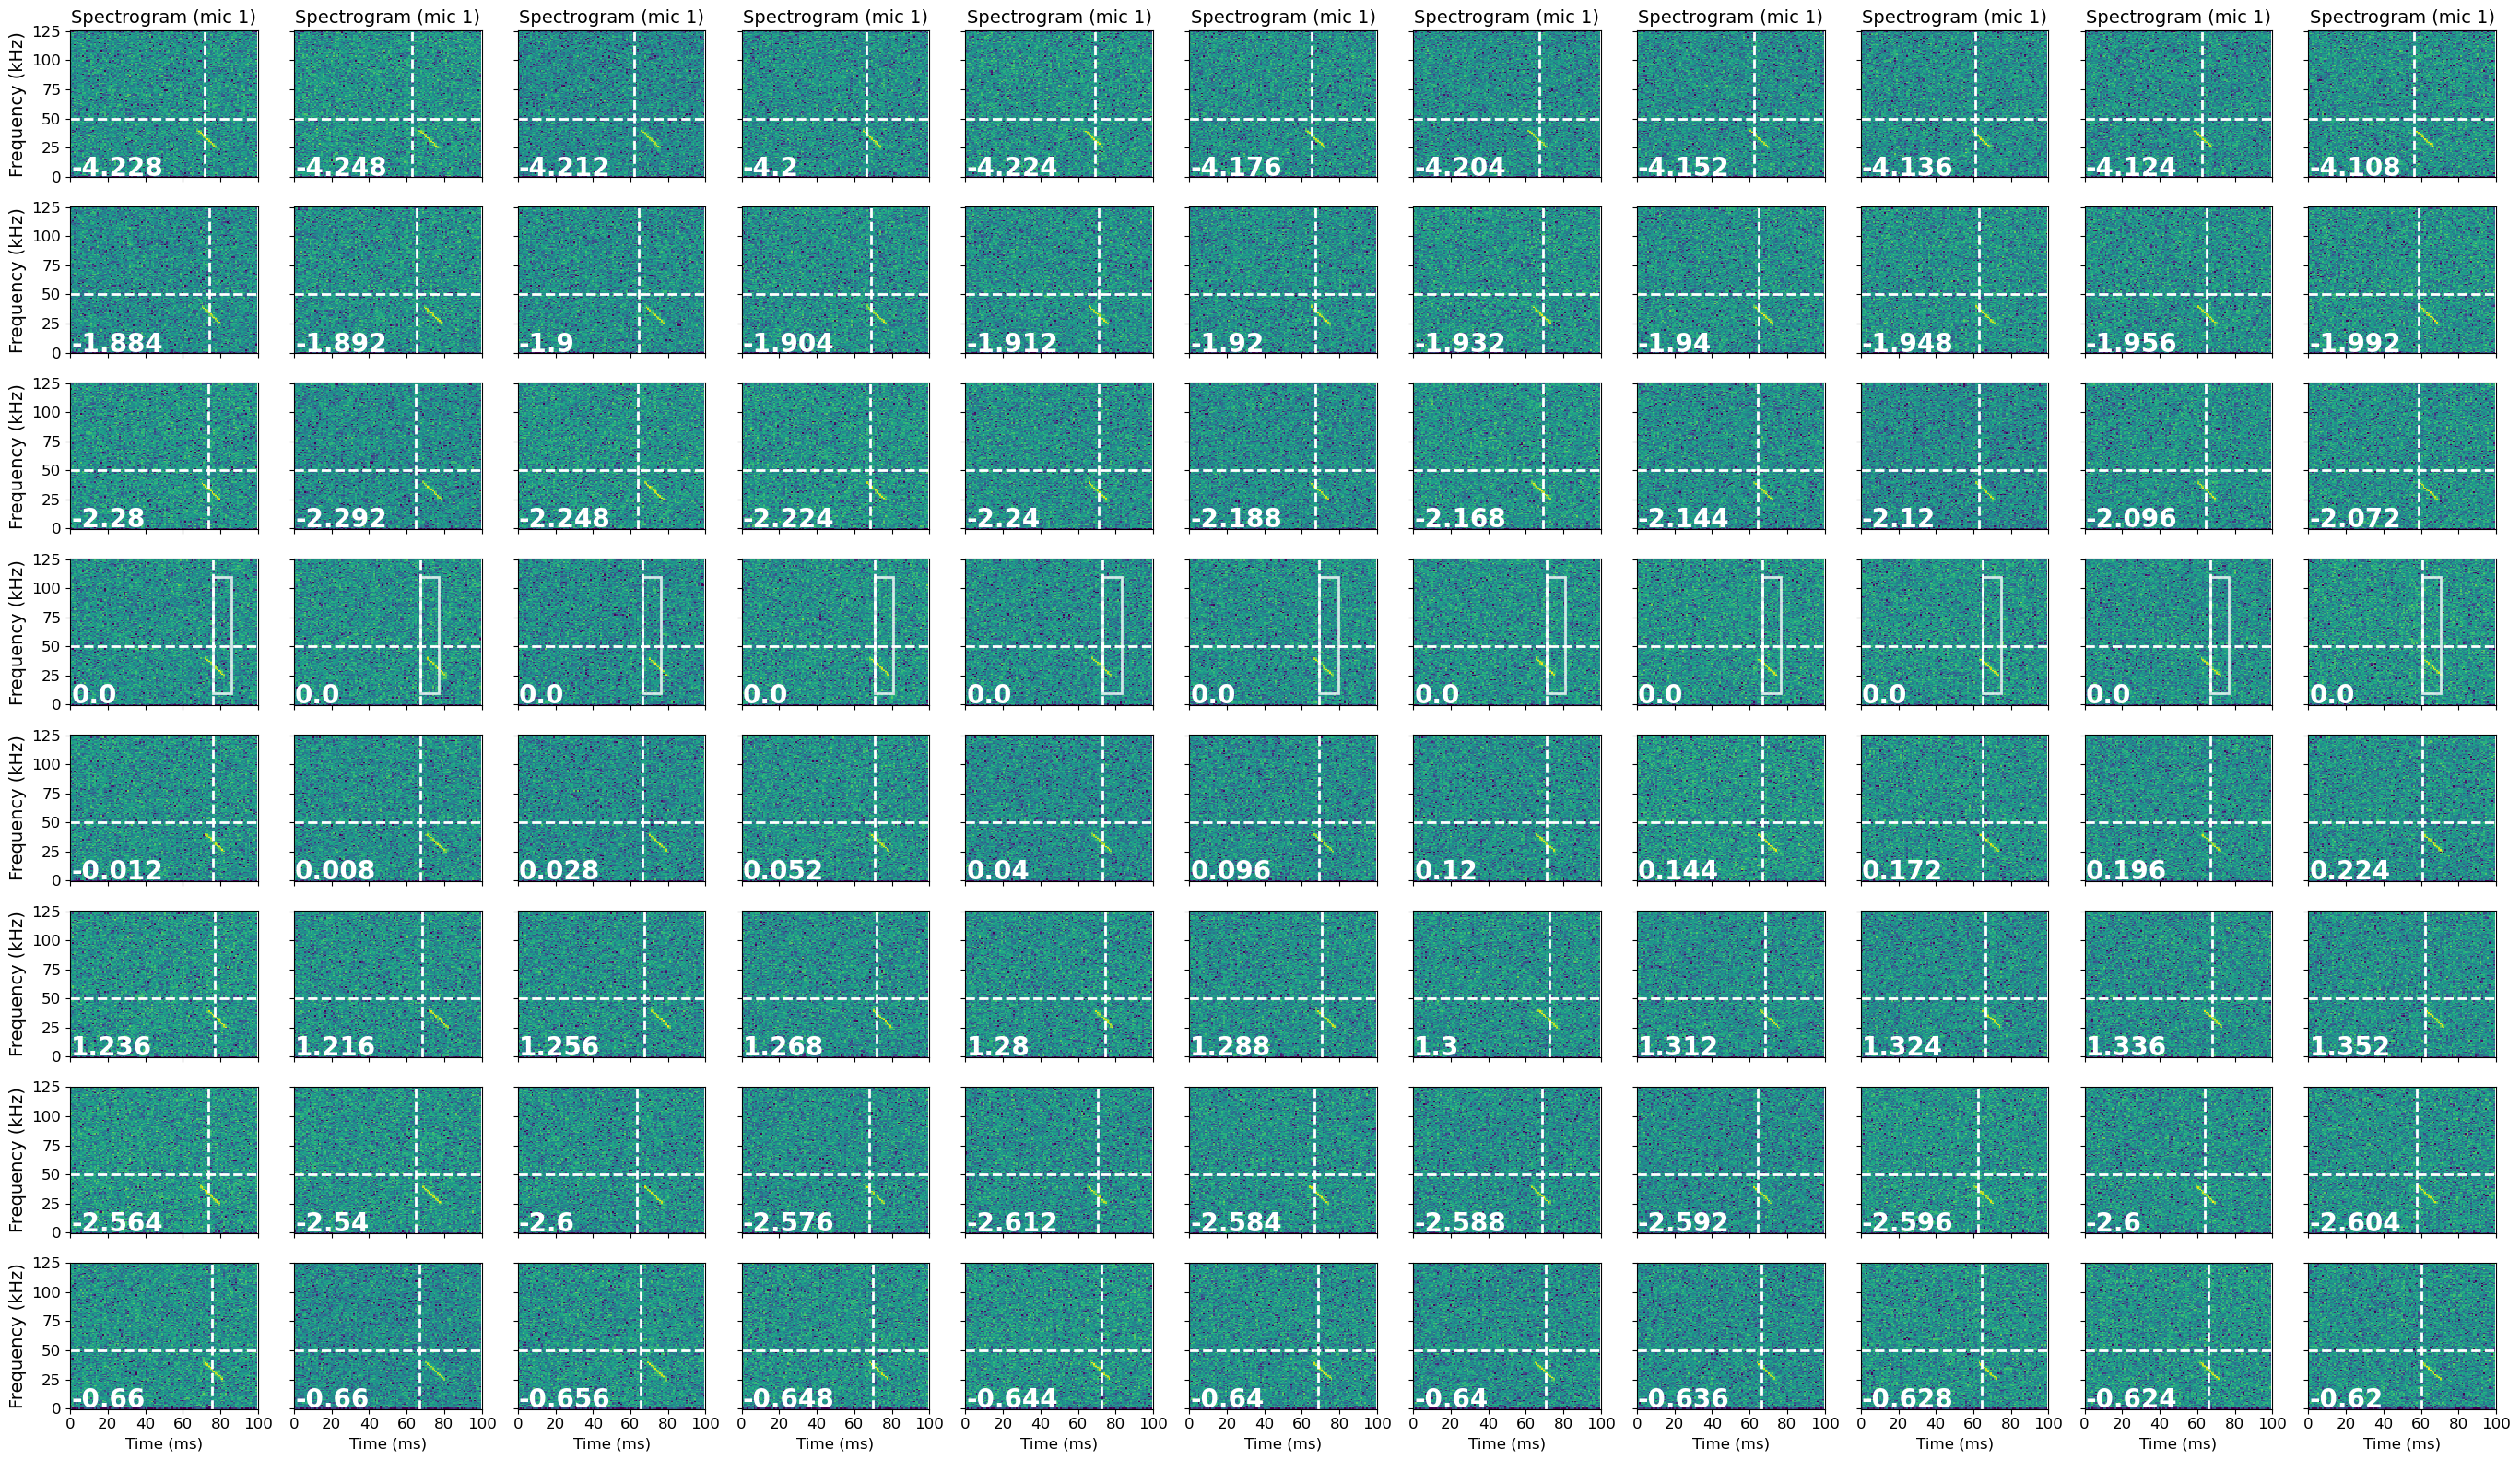

In [131]:
%matplotlib inline

example_t_delays_wrt_selected_channel = np.zeros((time_steps.size, NUM_GOOD_CHANNELS), dtype=np.float64)
channel_num = 0
plt.figure(figsize=(2.5*noisy_calls.shape[0], 2*NUM_GOOD_CHANNELS))
plt.rcParams.update({'font.size': 12})
for non_ref_call_i in range(NUM_GOOD_CHANNELS):
    for det_num in range(noisy_calls.shape[0]):
        channel_num+=1
        spec_features = dict()
        spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small (must always be > 128)
        spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
        spec_features['vmin'] = -80
        spec_features['vmax'] = 0

        nonref_dets = noisy_calls[det_num]
        approx_call_dur = 0.01
        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
        # ref_call_of_det, ref_channel_num = index_reference_call_based_on_feature_to_maximize(example_calls, det_num, example_snr_facs)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)

        signal1 = ref_call_of_det
        signal2 = ref_mic_call_only
        auto_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(auto_correlation)
        time_delay_in_samples = lags[max_lag_index]
        auto_time_delay_in_seconds = time_delay_in_samples / FS

        signal1 = nonref_dets[non_ref_call_i, :]
        signal2 = ref_mic_call_only
        cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / FS

        example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

        plt.subplot(NUM_GOOD_CHANNELS, noisy_calls.shape[0], channel_num)
        plt.rcParams.update({'font.size': 12})
        if non_ref_call_i==0:
            plt.title(f"Spectrogram (mic {MICROPHONES_USED[non_ref_call_i]})", fontsize=14)
        freqs, time, Sxx = scipy.signal.spectrogram(signal1, fs=FS, nfft=spec_features['NFFT'])
        Sxx[np.where(Sxx==0)] = 1e-16 ### <--- replace all zeros with very small values (-160dB) outside of the scale to avoid taking log10(0)
        SxxdB = 10 * np.log10(Sxx) - 10 * np.log10(np.max(Sxx))
        plt.pcolormesh(1e3*time, freqs/1e3, SxxdB, vmin=-40, vmax=-0) #, 'k')

        plt.text(x=1e3*0.0005,y=0.85,s=f'{round(1000*(time_delay_in_seconds-auto_time_delay_in_seconds), 3)}',color='w',fontsize=20,fontweight='bold')
        plt.axvline(x=1e3*time_delay_in_seconds, linestyle='dashed', linewidth=2, color='w')
        plt.axhline(y=50, linestyle='dashed', linewidth=2, color='w')
        ax = plt.gca()
        if non_ref_call_i==ref_channel_num:
            rect_call = patches.Rectangle((1e3*(found_call_start), (10)), 1e3*approx_call_dur, (100), 
                            linewidth=2, edgecolor='white', facecolor='none', alpha=0.8)
            ax.add_patch(rect_call)
        if det_num==0:
            plt.yticks(np.linspace(0, FS/2000, 6).astype('int'))
            plt.ylabel("Frequency (kHz)", fontsize=14)
        else:
            plt.yticks(ticks=np.linspace(0, FS/2000, 6), labels=['']*6)
        if non_ref_call_i==(NUM_GOOD_CHANNELS-1):
            plt.xticks((np.linspace(0, 1e3*signal_duration, 6)), rotation=0)
            plt.xlabel("Time (ms)")    
        else:
            plt.xticks((np.linspace(0, 1e3*signal_duration, 6)), labels=['']*6)

plt.tight_layout()
plt.show()

In [57]:
time_step = 8.7
time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
pos_x = x_arr[time_idx]
pos_y = y_arr[time_idx]
pos_z = z_arr[time_idx]

dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
receive_signaln_for_timestep = signal[:, None, None]
signal_duration_samples = np.arange(int(signal_duration * FS))
rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
noise_power_dB = -10 # dBFS
noise_power_lin = 10**(noise_power_dB/10)
noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)

noisy_calls = example_calls + noise_mat
noisy_calls.shape

(88, 8, 25000)

In [58]:
example_t_delays_wrt_selected_channel = np.zeros((time_steps.size, NUM_GOOD_CHANNELS), dtype=np.float64)
channel_num = 0
for non_ref_call_i in range(NUM_GOOD_CHANNELS):
    for det_num in range(noisy_calls.shape[0]):
        channel_num+=1
        nonref_dets = noisy_calls[det_num]
        approx_call_dur = 0.01
        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)

        signal1 = nonref_dets[non_ref_call_i, :]
        signal2 = ref_mic_call_only
        cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / FS

        example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

In [59]:
time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
for i in range(measured_d_mics_to_ref.shape[0]):
    dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
    A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
    wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
    xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
    source_locs[:,i] = xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))

valid_source_locs = source_locs[:,np.abs(source_locs[3,:])>0.5]

In [60]:
delta_source_loc = valid_source_locs[:3,1:] - valid_source_locs[:3,:-1]
delta_t = ASSUMED_BAT_IPI
measured_velocity = np.sqrt(np.sum((delta_source_loc**2),axis=0)) / delta_t
measured_velocity

array([11.45347991,  2.04562427, 13.76267248,  4.91905328,  4.29125945,
        7.23824755,  2.00594206,  4.02766233,  7.64518149,  2.41988382,
        3.40577385,  5.90377141,  4.82281922,  4.87453684, 13.71080384,
        5.29519396,  2.11686979,  7.70416575,  1.8908692 ,  2.71343045,
        1.9727381 , 14.294896  ,  5.35235913,  9.23390907,  2.61329559,
        6.59287134,  3.24000396,  5.70166901,  5.35433107,  4.02325565,
        5.58823993,  2.90454671,  6.41023838,  3.57575753,  7.97706524,
        3.33206018,  5.95157249,  3.34990511,  3.67813991,  5.39006463,
        7.86912594,  3.6627979 ,  3.63181579,  3.87526559,  6.67703724,
        3.74757235,  3.78450768,  5.82870573,  4.2985158 ,  4.42683984,
        4.03038268,  4.25421986,  4.07064003,  4.12830399,  3.90615172,
        4.33268097,  4.01840271,  3.96439469,  3.98233418,  4.05150867,
        3.95374937,  4.42718707,  3.9114814 ,  3.91976991,  5.7360987 ,
        3.76770098,  4.91446846,  4.52249225,  6.88046644,  3.51

In [61]:
true_time_delay_mics_to_selected_ref_channel = ((dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR) - (dist_from_source_to_r_n_arr[SELECTED_CHANNEL_FOR_REF,:] / SOUND_SPEED_AIR)).T
true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, IND_OF_SELECTED_CHANNEL, axis=1)

norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(true_d_mics_to_ref.shape[0], dtype=np.float64)
for i in range(true_d_mics_to_ref.shape[0]):
    dm0_column = true_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
    A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
    wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
    xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
    source_locs[:,i] = xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
    line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))

valid_source_locs = source_locs[:,np.abs(source_locs[3,:])>0.5]

In [62]:
delta_source_loc = valid_source_locs[:3,1:] - valid_source_locs[:3,:-1]
delta_t = ASSUMED_BAT_IPI
true_velocity = np.sqrt(np.sum((delta_source_loc**2),axis=0)) / delta_t
true_velocity

array([4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4.])

In [63]:
true_velocity.mean(), measured_velocity.mean()

(4.0000000000001865, 4.942174721770417)

In [74]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    
    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.plot(x_arr, y_arr, color='k', alpha=0.5, zorder=1, label=f"Source")
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.plot(x_arr, z_arr, color='k', alpha=0.5, zorder=1, label=f"Source")
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.plot(y_arr, z_arr, color='k', alpha=0.5, zorder=1, label=f"Source")
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [78]:
ASSUMED_BAT_SPEED

2.309401076758503

In [76]:
np.sqrt((ASSUMED_BAT_SPEED**2)+(ASSUMED_BAT_SPEED**2)+(ASSUMED_BAT_SPEED**2))

4.0

In [97]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_from_source_to_r_n_arr = (dist_from_source_to_r_n_arr[:,:] / SOUND_SPEED_AIR)
    true_time_delay_mics_to_selected_ref_channel = (time_from_source_to_r_n_arr - time_from_source_to_r_n_arr[IND_OF_SELECTED_CHANNEL,:]).T
    true_d_mics_to_ref = np.delete(true_time_delay_mics_to_selected_ref_channel * SOUND_SPEED_AIR, IND_OF_SELECTED_CHANNEL, axis=1)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, true_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(true_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(true_d_mics_to_ref.shape[0]-1):
        dm0_column = true_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))

        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        
    derivate_cond_a_vals = np.diff(cond_a_vals, prepend=np.NaN)
    valid_source_locs = source_locs[:,np.abs(derivate_cond_a_vals)<20]
    valid_source_locs = valid_source_locs[:,np.abs(valid_source_locs[3,:])>0.5]
    for i in range(valid_source_locs.shape[1]):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_2d_xy.scatter(valid_source_locs[0,i], valid_source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(valid_source_locs[0,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(valid_source_locs[1,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    dist_e = np.mean(np.sqrt(((valid_source_locs[0,:]-x_arr[1:-1])**2) + ((valid_source_locs[1,:]-y_arr[1:-1])**2) + ((valid_source_locs[2,:]-z_arr[1:-1])**2)))
    map_ax_2d_xy.text(x=-10, y=9, s=f'Mean distance error\n{dist_e:.6f}')
    
    plt.figure(figsize=(18, 2))
    plt.plot(derivate_cond_a_vals[:-1], marker='.')
    plt.grid(which='both')
    plt.ylabel('diff(Cond(A))')
    plt.xlabel('Source location time step')
    plt.ylim(-50, 50)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [72]:
np.sqrt((10**2)+(10**2))

14.142135623730951

In [98]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    signal = scipy.signal.unit_impulse(t.size, idx=int(time_transmitted*FS)) * 1000
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]

    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)
    
    time_received_at_rn = ((np.argmax(chunk_of_received_signaln_in_window_timestep, axis=0)) / FS).T
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))

        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        
    derivate_cond_a_vals = np.diff(cond_a_vals, prepend=np.NaN)
    valid_source_locs = source_locs[:,np.abs(derivate_cond_a_vals)<20]
    valid_source_locs = valid_source_locs[:,np.abs(valid_source_locs[3,:])>0.5]
    for i in range(valid_source_locs.shape[1]):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_2d_xy.scatter(valid_source_locs[0,i], valid_source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(valid_source_locs[0,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(valid_source_locs[1,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    dist_e = np.mean(np.sqrt(((valid_source_locs[0,:]-x_arr[1:-1])**2) + ((valid_source_locs[1,:]-y_arr[1:-1])**2) + ((valid_source_locs[2,:]-z_arr[1:-1])**2)))
    map_ax_2d_xy.text(x=-10, y=9, s=f'Mean distance error\n{dist_e:.6f}')
    
    plt.figure(figsize=(18, 2))
    plt.plot(derivate_cond_a_vals[:-1], marker='.')
    plt.grid(which='both')
    plt.ylabel('diff(Cond(A))')
    plt.xlabel('Source location time step')
    plt.ylim(-50, 50)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-10, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [133]:
def simulate_N_receivers(time_step, noise_power_dB):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat

    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, TEMPLATE_CHANNEL)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)
            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(18, 5))
    plt.rcParams.update({'font.size':12})
    gs = gridspec.GridSpec(1, 3, width_ratios=np.array([1, 1, 1]), wspace=0.3)
    map_ax_2d_xy = plt.subplot(gs[0, 0])
    map_ax_2d_xy.scatter(rN_x, rN_y, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xy.scatter(pos_x, pos_y, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xy.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xy.set_xlabel("X (meters)")
    map_ax_2d_xy.set_ylabel("Y (meters)")
    map_ax_2d_xy.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_xz = plt.subplot(gs[0, 1])
    map_ax_2d_xz.scatter(rN_x, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_xz.scatter(pos_x, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_xz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_xz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_xz.set_xlabel("X (meters)")
    map_ax_2d_xz.set_ylabel("Z (meters)")
    map_ax_2d_xz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    map_ax_2d_yz = plt.subplot(gs[0, 2])
    map_ax_2d_yz.scatter(rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    map_ax_2d_yz.scatter(pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_2d_yz.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_2d_yz.set_ylim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_2d_yz.set_xlabel("Y (meters)")
    map_ax_2d_yz.set_ylabel("Z (meters)")
    map_ax_2d_yz.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))

        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2

        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
        
    derivate_cond_a_vals = np.diff(cond_a_vals, prepend=np.NaN)
    valid_source_locs = source_locs[:,np.abs(derivate_cond_a_vals)<20]
    valid_source_locs = valid_source_locs[:,np.abs(valid_source_locs[3,:])>0.5]
    for i in range(valid_source_locs.shape[1]):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_2d_xy.scatter(valid_source_locs[0,i], valid_source_locs[1,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_xz.scatter(valid_source_locs[0,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        map_ax_2d_yz.scatter(valid_source_locs[1,i], valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    plt.figure(figsize=(18, 2))
    plt.plot(derivate_cond_a_vals[:-1], marker='.')
    plt.grid(which='both')
    plt.ylabel('diff(Cond(A))')
    plt.xlabel('Source location time step')
    plt.ylim(-50, 50)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

noise_slider = widgets.IntSlider(
    value=-90, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…

In [122]:
def simulate_N_receivers(time_step, noise_power_dB, template_channel, elevation, azim):
    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]
    A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
    A_locs_mat_wrt_ref_channel = A_LOCS_MAT
    A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

    x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
    y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
    z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
    xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
    ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
    zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))
    
    time_transmitted = TIME_DURATION/2
    t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
    raw_signal = scipy.signal.chirp(t, f0=40000, t1=0.01, f1=25000)
    template_signal = raw_signal[:int(FS*0.01)]
    signal = np.zeros(t.size)
    signal[int(FS*time_transmitted):int(FS*(time_transmitted+0.01))] = template_signal
    signal_duration = TIME_DURATION/2

    time_steps = np.arange(0, time_step+ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)
    time_idx = np.where(np.isclose(time_steps, time_step, atol=1e-2))[0][0]
    x_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    y_arr = ASSUMED_BAT_SPEED * (time_steps) - (BAT_INIT_DIST)
    z_arr = (-ASSUMED_BAT_SPEED * time_steps) + (2*BAT_INIT_DIST)
    pos_x = x_arr[time_idx]
    pos_y = y_arr[time_idx]
    pos_z = z_arr[time_idx]


    dist_from_source_to_r_n_arr = np.sqrt((x_arr[None, :] - rN_x[:, None]) ** 2 + (y_arr[None, :] - rN_y[:, None]) ** 2 + (z_arr[None, :] - rN_z[:, None]) ** 2)
    time_to_rn_array = dist_from_source_to_r_n_arr / SOUND_SPEED_AIR
    receive_signaln_for_timestep = signal[:, None, None]
    signal_duration_samples = np.arange(int(signal_duration * FS))
    rn_indices = ((time_transmitted - time_to_rn_array) * FS).astype(int) + signal_duration_samples[:, None, None]
    chunk_of_received_signaln_in_window_timestep = np.take_along_axis(receive_signaln_for_timestep, rn_indices, axis=0)

    example_calls = chunk_of_received_signaln_in_window_timestep[:,:,:].T
    noise_power_lin = 10**(noise_power_dB/10)
    noise_mat = np.random.normal(loc=0, scale=noise_power_lin, size=example_calls.shape)
    noisy_calls = example_calls + noise_mat
    
    example_t_delays_wrt_selected_channel = np.zeros((noisy_calls.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
    for non_ref_call_i in range(NUM_GOOD_CHANNELS):
        for det_num in range(noisy_calls.shape[0]):
            nonref_dets = noisy_calls[det_num]
            approx_call_dur = 0.01
            ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(noisy_calls, det_num, template_channel)
            ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(ref_call_of_det, approx_call_dur)
            signal1 = nonref_dets[non_ref_call_i, :]
            signal2 = ref_mic_call_only
            cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
            lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
            max_lag_index = np.argmax(cross_correlation)
            time_delay_in_samples = lags[max_lag_index]
            time_delay_in_seconds = time_delay_in_samples / FS
            example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

    time_received_at_rn = example_t_delays_wrt_selected_channel[:time_idx]
    t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
    time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
    time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
    measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':12})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])

    norm = plt.Normalize(vmin=0, vmax=TIMESTEPS.shape[0])
    source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]-1), dtype=np.float64)
    cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0]-1, dtype=np.float64)
    for i in range(measured_d_mics_to_ref.shape[0]-1):
        dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
        A_mat = np.hstack(((A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF] - A_locs_mat_tdoa_meters), dm0_column))
        wm0 = ((dm0_column**2) - (xm**2) + (x0**2) - (ym**2) + (y0**2) - (zm**2) + (z0**2))/2
        xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
        source_locs[:,i] = xs.reshape((1,4))
        cond_a_vals[i] = np.linalg.cond(A_mat)
    
        
    derivate_cond_a_vals = np.diff(cond_a_vals, prepend=np.NaN)
    valid_source_locs = source_locs[:,np.abs(derivate_cond_a_vals)<20]
    valid_source_locs = valid_source_locs[:,np.abs(valid_source_locs[3,:])>0.5]
    for i in range(source_locs.shape[1]):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_3d.scatter(source_locs[0,i], source_locs[1,i], 
                          source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)
        
    map_ax_3d.scatter(pos_x, pos_y, pos_z, edgecolors='red', facecolors='none', linewidths=2, s=50, label=f"Source")
    map_ax_3d.plot(source_locs[0,:], source_locs[1,:], source_locs[2,:], color='k', alpha=0.5, zorder=1)
    map_ax_3d.set_xlim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.legend(handles=marker_handles, ncol=2, loc='upper right')
    map_ax_3d.view_init(elev=elevation, azim=azim)

    plt.figure(figsize=(15, 2))
    plt.plot(derivate_cond_a_vals, marker='.')
    plt.grid(which='both')
    plt.ylabel('diff(Cond(A))')
    plt.xlabel('Source location time step')
    plt.ylim(-50, 50)

    plt.show()

time_slider = widgets.FloatSlider(
    value=TIMESTEPS[-1], min=0, max=TIMESTEPS[-1], step=ASSUMED_BAT_IPI, description="Time (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
noise_slider = widgets.IntSlider(
    value=-90, min=-90, max=0, step=1, description="Noise Power (dBFS)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
template_slider = widgets.IntSlider(
    value=0, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=1, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(simulate_N_receivers, time_step=time_slider, noise_power_dB=noise_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=8.700000000000001, description='Time (k)', layout=Layout(width='1000px…